In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import os
import re
from datetime import datetime
import openpyxl as op
import seaborn as sns

In [2]:
folder_path = 'Math_232_Data/jump_data_clean'
df_list = []

for file_name in os.listdir(folder_path):
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        
        # Extract the first part before the underscore
        base_name = os.path.splitext(file_name)[0]
        label = base_name.split('_')[0]
        df['Label'] = label
        
        df_list.append(df)

combined_df = pd.concat(df_list, ignore_index=True)

In [3]:
combined_df.head()

,Jump_Number,time_step_1,time_step_2,time_step_3,time_step_4,time_step_5,time_step_6,time_step_7,time_step_8,time_step_9,...,time_step_173,time_step_174,time_step_175,time_step_176,time_step_177,time_step_178,time_step_179,time_step_180,time_step_181,Label
0,1,333.32,333.60,333.84,333.92,334.52,335.12,335.36,335.68,335.56,...,130.64,139.92,149.32,158.80,170.48,181.64,191.00,198.60,204.40,leo
1,2,87.80,86.20,86.08,88.24,92.00,95.52,98.32,100.48,102.04,...,351.40,351.48,352.52,353.00,354.28,354.80,355.92,356.52,357.04,leo
2,3,341.16,343.16,344.88,347.76,350.16,351.92,353.40,355.44,355.88,...,256.92,250.28,245.08,240.80,238.40,237.52,236.92,235.04,230.04,leo
3,4,154.76,163.24,177.64,191.92,206.92,220.88,234.96,242.36,250.04,...,198.08,221.64,241.48,256.64,266.88,272.08,274.60,276.84,279.16,leo
4,5,172.64,198.08,221.64,241.48,256.64,266.88,272.08,274.60,276.84,...,351.44,348.92,344.88,339.84,335.04,329.12,323.44,317.76,312.80,leo


In [4]:
combined_df.shape

(245, 183)

# Perform SVD + PCA

In [5]:
# check NA values
combined_df.isna().sum().sum()

np.int64(0)

In [6]:
# standardize data
data = combined_df.iloc[:, 1:182]

X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (245, 181)
s shape: (181,)
Vt shape: (181, 181)


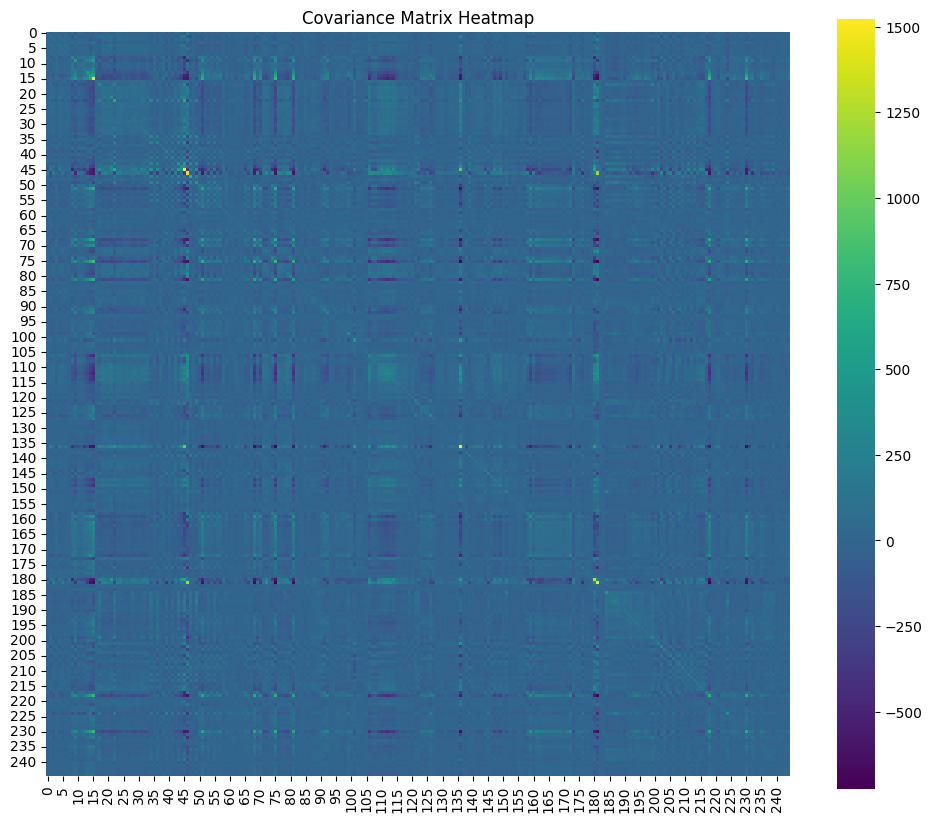

Shape of covariance matrix: (245, 245)

Maximum value: 1522.718746662276
Minimum value: -724.6621970778432
Mean value: -5.681974396748823e-17


In [7]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

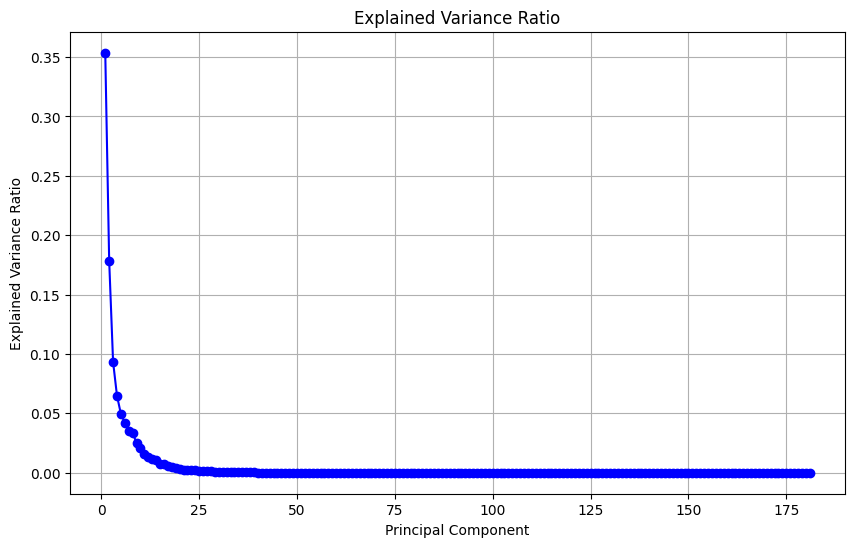

In [8]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [9]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.3536
PC2: 0.5323
PC3: 0.6256
PC4: 0.6903
PC5: 0.7398
PC6: 0.7818
PC7: 0.8166
PC8: 0.8497
PC9: 0.8750
PC10: 0.8954
PC11: 0.9109
PC12: 0.9241
PC13: 0.9355
PC14: 0.9459
PC15: 0.9536
PC16: 0.9606
PC17: 0.9665
PC18: 0.9717
PC19: 0.9757
PC20: 0.9792
PC21: 0.9817
PC22: 0.9841
PC23: 0.9861
PC24: 0.9880
PC25: 0.9895
PC26: 0.9909
PC27: 0.9920
PC28: 0.9931
PC29: 0.9940
PC30: 0.9948
PC31: 0.9955
PC32: 0.9961
PC33: 0.9966
PC34: 0.9970
PC35: 0.9974
PC36: 0.9977
PC37: 0.9980
PC38: 0.9982
PC39: 0.9984
PC40: 0.9986
PC41: 0.9988
PC42: 0.9989
PC43: 0.9990
PC44: 0.9991
PC45: 0.9992
PC46: 0.9993
PC47: 0.9994
PC48: 0.9995
PC49: 0.9995
PC50: 0.9995
PC51: 0.9996
PC52: 0.9996
PC53: 0.9996
PC54: 0.9997
PC55: 0.9997
PC56: 0.9997
PC57: 0.9997
PC58: 0.9998
PC59: 0.9998
PC60: 0.9998
PC61: 0.9998
PC62: 0.9998
PC63: 0.9998
PC64: 0.9999
PC65: 0.9999
PC66: 0.9999
PC67: 0.9999
PC68: 0.9999
PC69: 0.9999
PC70: 0.9999
PC71: 0.9999
PC72: 0.9999
PC73: 0.9999
PC74: 0.9999
PC75: 0.99

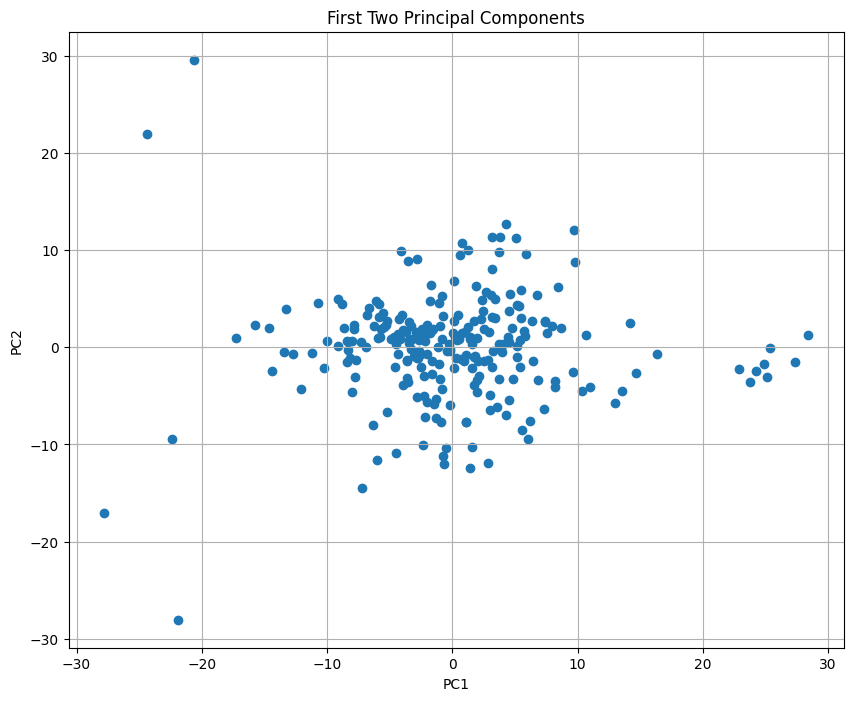

In [10]:
# Plot the first two principal components
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

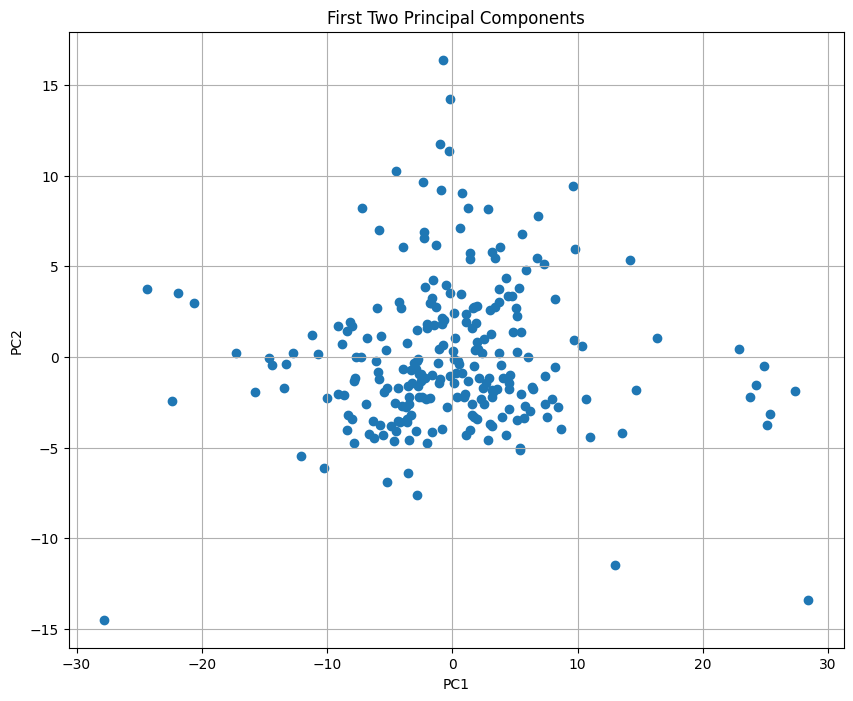

In [11]:
# Plot the first and third PC
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 2])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()